# Arithmetic-Geometric Mean

We study convergence of $(a_k,g_k)$ and the surface $(x,y)\mapsto\mathrm{AG}(x,y)$.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

M = 450
a0 = rng.uniform(0.2, 3.0, size=M)
g0 = rng.uniform(0.2, 3.0, size=M)
K = 16
A = [a0.copy()]; G = [g0.copy()]
a, g = a0.copy(), g0.copy()
for _ in range(K):
    a, g = 0.5*(a+g), np.sqrt(a*g)
    A.append(a.copy()); G.append(g.copy())
A = np.array(A); G = np.array(G)
gap = np.mean(np.abs(A-G), axis=1)


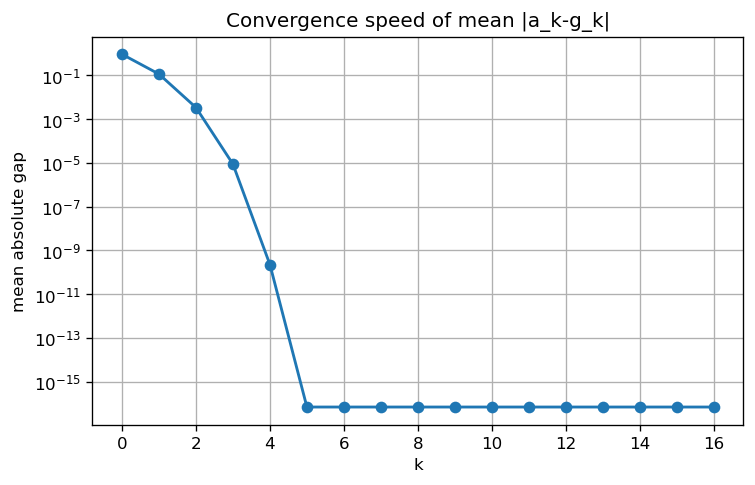

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.semilogy(gap, 'o-', lw=1.7)
ax.set_title('Convergence speed of mean |a_k-g_k|')
ax.set_xlabel('k'); ax.set_ylabel('mean absolute gap')
plt.show()


## Surface map of AGM


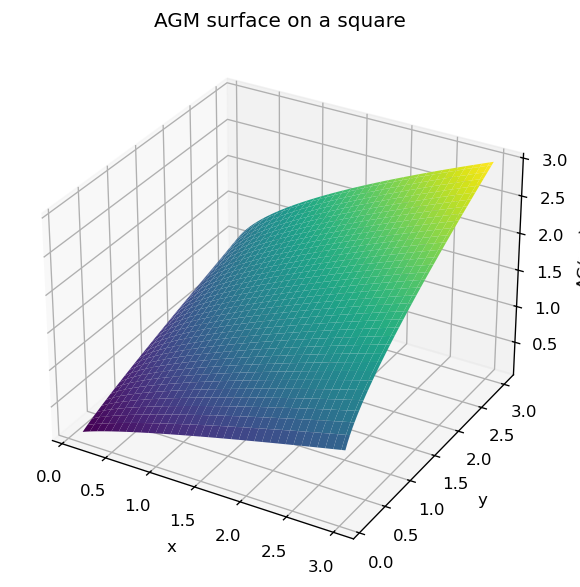

In [3]:
xx = np.linspace(0.1, 3.0, 70)
yy = np.linspace(0.1, 3.0, 70)
XX, YY = np.meshgrid(xx, yy)
AA, GG = XX.copy(), YY.copy()
for _ in range(15):
    AA, GG = 0.5*(AA+GG), np.sqrt(AA*GG)
AG = 0.5*(AA+GG)

fig = plt.figure(figsize=(8.0, 5.8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(XX, YY, AG, cmap='viridis', linewidth=0, antialiased=True)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('AG(x,y)')
ax.set_title('AGM surface on a square')
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
